In [2]:
import mne
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("MNE:", mne.__version__)

MNE: 1.12.1


In [ ]:
from pathlib import Path


raw_dir = Path("../data/raw")


if not raw_dir.exists():
    raw_dir = Path("data/raw")

print("Raw-Ordner:", raw_dir.resolve())

csv_files = sorted(raw_dir.rglob("*.csv"))

print("Gefundene CSV-Dateien:", len(csv_files))

for f in csv_files[:30]:
    print(f)

Raw-Ordner: E:\eeg-flex2-pipeline\data\raw
Gefundene CSV-Dateien: 395
data\raw\SUBJECT01\SUBJECT01_Trial_01_EEG.csv
data\raw\SUBJECT01\SUBJECT01_Trial_01_EMG.csv
data\raw\SUBJECT01\SUBJECT01_Trial_02_EEG.csv
data\raw\SUBJECT01\SUBJECT01_Trial_02_EMG.csv
data\raw\SUBJECT01\SUBJECT01_Trial_03_EEG.csv
data\raw\SUBJECT01\SUBJECT01_Trial_03_EMG.csv
data\raw\SUBJECT01\SUBJECT01_Trial_04_EEG.csv
data\raw\SUBJECT01\SUBJECT01_Trial_04_EMG.csv
data\raw\SUBJECT01\SUBJECT01_Trial_05_EEG.csv
data\raw\SUBJECT01\SUBJECT01_Trial_05_EMG.csv
data\raw\SUBJECT02\SUBJECT02_Trial_01_EEG.csv
data\raw\SUBJECT02\SUBJECT02_Trial_01_EMG.csv
data\raw\SUBJECT02\SUBJECT02_Trial_02_EEG.csv
data\raw\SUBJECT02\SUBJECT02_Trial_02_EMG.csv
data\raw\SUBJECT02\SUBJECT02_Trial_03_EEG.csv
data\raw\SUBJECT02\SUBJECT02_Trial_03_EMG.csv
data\raw\SUBJECT02\SUBJECT02_Trial_04_EEG.csv
data\raw\SUBJECT02\SUBJECT02_Trial_04_EMG.csv
data\raw\SUBJECT02\SUBJECT02_Trial_05_EEG.csv
data\raw\SUBJECT02\SUBJECT02_Trial_05_EMG.csv
data\raw\S

In [4]:
import pandas as pd

first_csv = csv_files[0]
print("Erste CSV:", first_csv)

df = pd.read_csv(first_csv)

print("Shape:", df.shape)
print("Spalten:")
print(df.columns.tolist())

df.head()

Erste CSV: data\raw\SUBJECT01\SUBJECT01_Trial_01_EEG.csv
Shape: (12865, 39)
Spalten:
['Triggers', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37']


,Triggers,0,1,2,3,4,5,6,7,8,...,28,29,30,31,32,33,34,35,36,37
0,771,121,0,-4.858,7.761,10.156,0.423,-6.168,8.306,2.003,...,-11.536,15.973,3.681,-3.154,81.163,21.481,3968,0,0,0
1,0,122,0,-25.346,-15.813,-5.735,-12.898,-0.014,-8.609,-14.905,...,-17.672,2.125,-13.742,-15.959,56.491,7.115,3968,0,0,0
2,0,123,0,-18.148,-11.699,-5.217,-10.836,-1.038,-0.916,-9.255,...,-7.408,-0.951,-2.969,-7.746,61.558,16.842,3968,0,0,0
3,0,124,0,-14.544,-4.515,-4.700,-13.899,-23.066,3.696,-12.319,...,-12.012,0.075,-1.429,-8.763,58.422,14.775,3968,0,0,0
4,0,125,0,-27.849,-16.293,-11.867,-27.717,-37.388,-10.140,-19.479,...,-21.221,-4.024,-12.699,-16.951,47.093,2.465,3968,0,0,0


In [5]:
print(first_csv)
print(df.shape)
print(df.columns.tolist())
df.head()

data\raw\SUBJECT01\SUBJECT01_Trial_01_EEG.csv
(12865, 39)
['Triggers', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37']


,Triggers,0,1,2,3,4,5,6,7,8,...,28,29,30,31,32,33,34,35,36,37
0,771,121,0,-4.858,7.761,10.156,0.423,-6.168,8.306,2.003,...,-11.536,15.973,3.681,-3.154,81.163,21.481,3968,0,0,0
1,0,122,0,-25.346,-15.813,-5.735,-12.898,-0.014,-8.609,-14.905,...,-17.672,2.125,-13.742,-15.959,56.491,7.115,3968,0,0,0
2,0,123,0,-18.148,-11.699,-5.217,-10.836,-1.038,-0.916,-9.255,...,-7.408,-0.951,-2.969,-7.746,61.558,16.842,3968,0,0,0
3,0,124,0,-14.544,-4.515,-4.700,-13.899,-23.066,3.696,-12.319,...,-12.012,0.075,-1.429,-8.763,58.422,14.775,3968,0,0,0
4,0,125,0,-27.849,-16.293,-11.867,-27.717,-37.388,-10.140,-19.479,...,-21.221,-4.024,-12.699,-16.951,47.093,2.465,3968,0,0,0


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Triggers,12865.0,15.971551,420.647147,0.000,0.000,0.000,0.000,32766.000
0,12865.0,63.380490,36.974021,0.000,31.000,63.000,95.000,127.000
1,12865.0,0.003576,0.059692,0.000,0.000,0.000,0.000,1.000
2,12865.0,4.422931,45.842751,-236.383,-8.966,6.267,21.728,257.227
3,12865.0,6.815479,40.835609,-195.220,-8.620,6.928,23.884,225.239
4,12865.0,6.344504,36.175682,-179.767,-7.358,6.511,21.542,176.374
5,12865.0,8.275475,37.606723,-158.342,-12.408,6.736,26.428,167.525
6,12865.0,12.759549,30.224801,-88.122,-6.031,11.870,29.068,159.453
7,12865.0,8.163919,35.523289,-175.154,-7.463,7.668,23.766,164.146
8,12865.0,5.714542,41.541509,-199.665,-7.332,7.187,23.233,202.586


In [7]:
print("Trigger-Werte:")
print(df["Triggers"].value_counts().head(20))

trigger_rows = df.index[df["Triggers"] != 0].tolist()
print("Anzahl Trigger-Zeilen:", len(trigger_rows))
print("Erste Trigger-Zeilen:", trigger_rows[:20])

df.loc[trigger_rows[:20], ["Triggers"]]

Trigger-Werte:
Triggers
0        12823
771         10
7711        10
7712        10
1000        10
768          1
32766        1
Name: count, dtype: int64
Anzahl Trigger-Zeilen: 42
Erste Trigger-Zeilen: [0, 154, 793, 1050, 1286, 1478, 2108, 2372, 2550, 2742, 3386, 3641, 3838, 4030, 4670, 4927, 5085, 5276, 5915, 6173]


,Triggers
0,771
154,7711
793,7712
1050,1000
1286,771
1478,7711
2108,7712
2372,1000
2550,771
2742,7711


In [8]:
eeg_cols = [str(i) for i in range(2, 34)]

print("Vermutete EEG-Spalten:", eeg_cols)
print("Anzahl:", len(eeg_cols))

df[eeg_cols].describe().T

Vermutete EEG-Spalten: ['2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33']
Anzahl: 32


,count,mean,std,min,25%,50%,75%,max
2,12865.0,4.422931,45.842751,-236.383,-8.966,6.267,21.728,257.227
3,12865.0,6.815479,40.835609,-195.220,-8.620,6.928,23.884,225.239
4,12865.0,6.344504,36.175682,-179.767,-7.358,6.511,21.542,176.374
5,12865.0,8.275475,37.606723,-158.342,-12.408,6.736,26.428,167.525
6,12865.0,12.759549,30.224801,-88.122,-6.031,11.870,29.068,159.453
7,12865.0,8.163919,35.523289,-175.154,-7.463,7.668,23.766,164.146
8,12865.0,5.714542,41.541509,-199.665,-7.332,7.187,23.233,202.586
9,12865.0,5.312640,28.869770,-138.965,-8.587,4.955,18.704,149.064
10,12865.0,3.694681,41.201858,-210.422,-7.136,5.864,18.566,207.282
11,12865.0,2.524583,29.168893,-130.080,-12.898,3.968,18.869,132.069


In [ ]:
import mne
import numpy as np
from pathlib import Path


eeg_cols = [str(i) for i in range(2, 34)]


sfreq = 128


eeg_data = df[eeg_cols].to_numpy().T


eeg_data = eeg_data * 1e-6


stim_data = df["Triggers"].to_numpy()[None, :]

data = np.vstack([eeg_data, stim_data])

ch_names = [f"EEG{i+1:02d}" for i in range(32)] + ["STI 014"]
ch_types = ["eeg"] * 32 + ["stim"]

info = mne.create_info(
    ch_names=ch_names,
    sfreq=sfreq,
    ch_types=ch_types
)

raw = mne.io.RawArray(data, info)

print(raw)
print("Dauer in Sekunden:", raw.times[-1])
print("Kanäle:", raw.ch_names)


Creating RawArray with float64 data, n_channels=33, n_times=12865
    Range : 0 ... 12864 =      0.000 ...   100.500 secs
Ready.
<RawArray | 33 x 12865 (100.5 s), ~3.3 MiB, data loaded>
Dauer in Sekunden: 100.5
Kanäle: ['EEG01', 'EEG02', 'EEG03', 'EEG04', 'EEG05', 'EEG06', 'EEG07', 'EEG08', 'EEG09', 'EEG10', 'EEG11', 'EEG12', 'EEG13', 'EEG14', 'EEG15', 'EEG16', 'EEG17', 'EEG18', 'EEG19', 'EEG20', 'EEG21', 'EEG22', 'EEG23', 'EEG24', 'EEG25', 'EEG26', 'EEG27', 'EEG28', 'EEG29', 'EEG30', 'EEG31', 'EEG32', 'STI 014']


In [ ]:
trig = df["Triggers"].to_numpy()

event_samples = np.where((trig != 0) & (np.r_[0, trig[:-1]] == 0))[0]
event_ids = trig[event_samples].astype(int)

events = np.column_stack([
    event_samples,
    np.zeros(len(event_samples), dtype=int),
    event_ids
])

print("Events:", events.shape)
print(events[:20])

Events: (41, 3)
[[   0    0  771]
 [ 154    0 7711]
 [ 793    0 7712]
 [1050    0 1000]
 [1286    0  771]
 [1478    0 7711]
 [2108    0 7712]
 [2372    0 1000]
 [2550    0  771]
 [2742    0 7711]
 [3386    0 7712]
 [3641    0 1000]
 [3838    0  771]
 [4030    0 7711]
 [4670    0 7712]
 [4927    0 1000]
 [5085    0  771]
 [5276    0 7711]
 [5915    0 7712]
 [6173    0 1000]]


In [11]:
raw.plot(
    duration=10,
    n_channels=33,
    scalings="auto"
)

Using qt as 2D backend.


<mne_qt_browser._pg_figure.MNEQtBrowser(0x25611cbb4f0) at 0x0000025613C63EC0>

Channels marked as bad:
none
Attempting to create new mne-python configuration file:
C:\Users\grisc\.mne\mne-python.json
Could not read the C:\Users\grisc\.mne\mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)


E:\conda-envs\eeg-mne\Lib\site-packages\mne_qt_browser\_utils.py:36: RuntimeWarning: libpyside: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()
E:\conda-envs\eeg-mne\Lib\site-packages\mne_qt_browser\_utils.py:36: RuntimeWarning: libpyside: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()
E:\conda-envs\eeg-mne\Lib\site-packages\mne_qt_browser\_utils.py:36: RuntimeWarning: libpyside: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()
E:\conda-envs\eeg-mne\Lib\site-packages\mne_qt_browser\_utils.py:36: RuntimeWarning: libpyside: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()
E:\conda-envs\eeg-mne\Lib\site-packages\mne_qt_browser\_utils.py:36: RuntimeWarning: libpyside: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()


Channels marked as bad:
none


E:\conda-envs\eeg-mne\Lib\site-packages\mne_qt_browser\_utils.py:36: RuntimeWarning: libpyside: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()
E:\conda-envs\eeg-mne\Lib\site-packages\mne_qt_browser\_utils.py:36: RuntimeWarning: libpyside: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()
E:\conda-envs\eeg-mne\Lib\site-packages\mne_qt_browser\_utils.py:36: RuntimeWarning: libpyside: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()
E:\conda-envs\eeg-mne\Lib\site-packages\mne_qt_browser\_utils.py:36: RuntimeWarning: libpyside: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()
E:\conda-envs\eeg-mne\Lib\site-packages\mne_qt_browser\_utils.py:36: RuntimeWarning: libpyside: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()


In [ ]:
raw_filtered = raw.copy()

raw_filtered.filter(
    l_freq=1.0,
    h_freq=40.0,
    picks="eeg"
)

raw_filtered.set_eeg_reference("average")

raw_filtered.plot(
    duration=10,
    n_channels=32,
    scalings="auto"
)

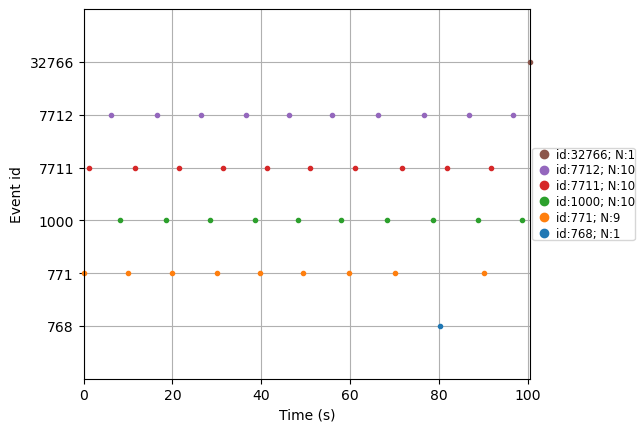

In [13]:
import matplotlib.pyplot as plt

mne.viz.plot_events(
    events,
    sfreq=sfreq,
    first_samp=raw.first_samp
)

plt.show()

In [ ]:
event_id = {
    "event_7711": 7711
}

epochs = mne.Epochs(
    raw_filtered,
    events,
    event_id=event_id,
    tmin=-1.0,
    tmax=2.0,
    baseline=(-1.0, 0.0),
    picks="eeg",
    preload=True
)

print(epochs)

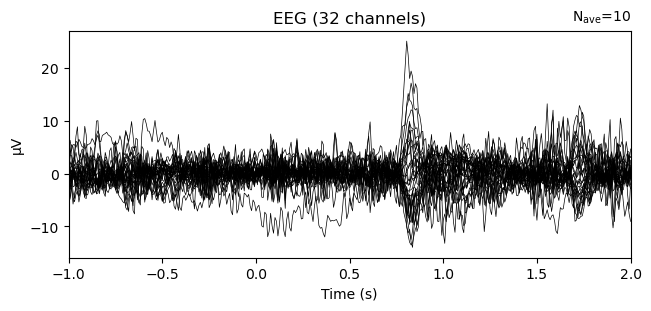

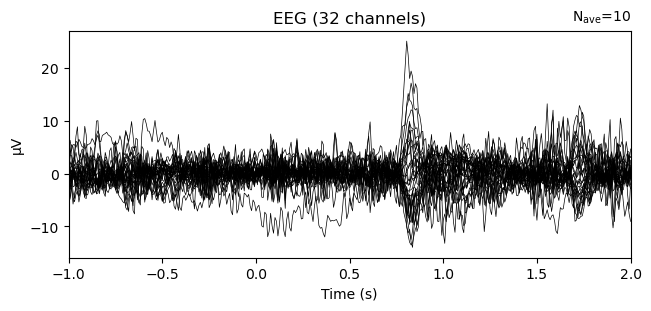

In [15]:
evoked = epochs.average()
evoked.plot()

In [ ]:
raw_mrcp = raw.copy()

raw_mrcp.filter(
    l_freq=0.1,
    h_freq=3.0,
    picks="eeg"
)

raw_mrcp.set_eeg_reference("average")

In [ ]:
epochs_mrcp = mne.Epochs(
    raw_mrcp,
    events,
    event_id={"event_7711": 7711},
    tmin=-2.0,
    tmax=2.0,
    baseline=(-2.0, -1.0),
    picks="eeg",
    preload=True
)

print(epochs_mrcp)

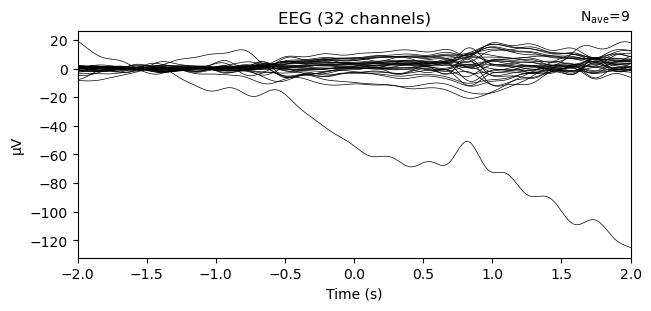

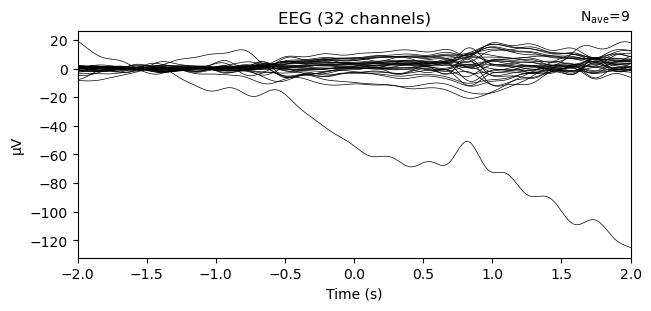

In [18]:
evoked_mrcp = epochs_mrcp.average()
evoked_mrcp.plot()

In [19]:
doc_files = []

for ext in ["*.txt", "*.pdf", "*.docx", "*.xlsx", "*.csv"]:
    doc_files.extend(raw_dir.rglob(ext))

for f in doc_files[:150]:
    print(f)

data\raw\SUBJECT11\SUBJECT11_Trial_01_EEG.xlsx
data\raw\SUBJECT11\SUBJECT11_Trial_02_EEG.xlsx
data\raw\SUBJECT11\SUBJECT11_Trial_03_EEG.xlsx
data\raw\SUBJECT11\SUBJECT11_Trial_04_EEG.xlsx
data\raw\SUBJECT11\SUBJECT11_Trial_05_EEG.xlsx
data\raw\SUBJECT01\SUBJECT01_Trial_01_EEG.csv
data\raw\SUBJECT01\SUBJECT01_Trial_01_EMG.csv
data\raw\SUBJECT01\SUBJECT01_Trial_02_EEG.csv
data\raw\SUBJECT01\SUBJECT01_Trial_02_EMG.csv
data\raw\SUBJECT01\SUBJECT01_Trial_03_EEG.csv
data\raw\SUBJECT01\SUBJECT01_Trial_03_EMG.csv
data\raw\SUBJECT01\SUBJECT01_Trial_04_EEG.csv
data\raw\SUBJECT01\SUBJECT01_Trial_04_EMG.csv
data\raw\SUBJECT01\SUBJECT01_Trial_05_EEG.csv
data\raw\SUBJECT01\SUBJECT01_Trial_05_EMG.csv
data\raw\SUBJECT02\SUBJECT02_Trial_01_EEG.csv
data\raw\SUBJECT02\SUBJECT02_Trial_01_EMG.csv
data\raw\SUBJECT02\SUBJECT02_Trial_02_EEG.csv
data\raw\SUBJECT02\SUBJECT02_Trial_02_EMG.csv
data\raw\SUBJECT02\SUBJECT02_Trial_03_EEG.csv
data\raw\SUBJECT02\SUBJECT02_Trial_03_EMG.csv
data\raw\SUBJECT02\SUBJECT02_

In [20]:
from pathlib import Path

raw_dir = Path("data/raw")
if not raw_dir.exists():
    raw_dir = Path("../data/raw")

print("Raw dir:", raw_dir.resolve())

for p in raw_dir.iterdir():
    print(p, "DIR" if p.is_dir() else "FILE")

Raw dir: E:\eeg-flex2-pipeline\data\raw
data\raw\.ipynb_checkpoints DIR
data\raw\SUBJECT01 DIR
data\raw\SUBJECT02 DIR
data\raw\SUBJECT03 DIR
data\raw\SUBJECT04 DIR
data\raw\SUBJECT05 DIR
data\raw\SUBJECT06 DIR
data\raw\SUBJECT07 DIR
data\raw\SUBJECT08 DIR
data\raw\SUBJECT09 DIR
data\raw\SUBJECT10 DIR
data\raw\SUBJECT11 DIR
data\raw\SUBJECT12 DIR
data\raw\SUBJECT13 DIR
data\raw\SUBJECT14 DIR
data\raw\SUBJECT15 DIR
data\raw\SUBJECT16 DIR
data\raw\SUBJECT17 DIR
data\raw\SUBJECT18 DIR
data\raw\SUBJECT19 DIR
data\raw\SUBJECT20 DIR
data\raw\SUBJECT21 DIR
data\raw\SUBJECT22 DIR
data\raw\SUBJECT23 DIR
data\raw\SUBJECT24 DIR
data\raw\SUBJECT25 DIR
data\raw\SUBJECT26 DIR
data\raw\SUBJECT27 DIR
data\raw\SUBJECT28 DIR
data\raw\SUBJECT29 DIR
data\raw\SUBJECT30 DIR
data\raw\SUBJECT31 DIR
data\raw\SUBJECT32 DIR
data\raw\SUBJECT33 DIR
data\raw\SUBJECT34 DIR
data\raw\SUBJECT35 DIR
data\raw\SUBJECT36 DIR
data\raw\SUBJECT37 DIR
data\raw\SUBJECT38 DIR
data\raw\SUBJECT39 DIR
data\raw\SUBJECT40 DIR


In [ ]:
eeg_cols = [str(i) for i in range(2, 34)]

eeg_ch_names = [
    "AF3", "AF4",
    "F3", "F1", "Fz", "F2", "F4",
    "FC3", "FC1", "FCz", "FC2", "FC4",
    "C3", "C1", "Cz", "C2", "C4",
    "CP3", "CP1", "CPz", "CP2", "CP4",
    "P3", "P1", "Pz", "P2", "P4",
    "PO3", "POz", "PO4",
    "O1", "O2"
]

print("EEG-Spalten:", len(eeg_cols))
print("Kanalnamen:", len(eeg_ch_names))

In [22]:
from pathlib import Path
import pandas as pd
import numpy as np
import mne

raw_dir = Path("../data/raw")
if not raw_dir.exists():
    raw_dir = Path("data/raw")

sfreq = 128
eeg_cols = [str(i) for i in range(2, 34)]

def load_eeg_csv_as_raw(csv_path, sfreq=128):
    df = pd.read_csv(csv_path)

    eeg_data = df[eeg_cols].to_numpy().T * 1e-6
    stim_data = df["Triggers"].to_numpy()[None, :]

    data = np.vstack([eeg_data, stim_data])

    ch_names = [f"EEG{i+1:02d}" for i in range(32)] + ["STI 014"]
    ch_types = ["eeg"] * 32 + ["stim"]

    info = mne.create_info(
        ch_names=ch_names,
        sfreq=sfreq,
        ch_types=ch_types
    )

    raw = mne.io.RawArray(data, info, verbose=False)
    return raw, df


def extract_events_from_df(df):
    trig = df["Triggers"].to_numpy()

    event_samples = np.where((trig != 0) & (np.r_[0, trig[:-1]] == 0))[0]
    event_ids = trig[event_samples].astype(int)

    events = np.column_stack([
        event_samples,
        np.zeros(len(event_samples), dtype=int),
        event_ids
    ])

    return events

In [ ]:
subject01_files = sorted((raw_dir / "SUBJECT01").glob("*_EEG.csv"))

print("Gefundene EEG-Trials:", len(subject01_files))

for f in subject01_files:
    print(f.name)

In [ ]:
for csv_file in subject01_files:
    raw_tmp, df_tmp = load_eeg_csv_as_raw(csv_file)
    events_tmp = extract_events_from_df(df_tmp)

    unique, counts = np.unique(events_tmp[:, 2], return_counts=True)
    
    print("\n", csv_file.name)
    for u, c in zip(unique, counts):
        print(f"Event {u}: {c}x")

In [ ]:
all_epochs = []

for csv_file in subject01_files:
    print("Verarbeite:", csv_file.name)

    raw_tmp, df_tmp = load_eeg_csv_as_raw(csv_file)
    events_tmp = extract_events_from_df(df_tmp)

    raw_tmp.filter(
        l_freq=1.0,
        h_freq=40.0,
        picks="eeg",
        verbose=False
    )

    raw_tmp.set_eeg_reference("average", verbose=False)

    epochs_tmp = mne.Epochs(
        raw_tmp,
        events_tmp,
        event_id={"event_7711": 7711},
        tmin=-1.0,
        tmax=2.0,
        baseline=(-1.0, 0.0),
        picks="eeg",
        preload=True,
        verbose=False
    )

    all_epochs.append(epochs_tmp)

epochs_subject01 = mne.concatenate_epochs(all_epochs)

print(epochs_subject01)

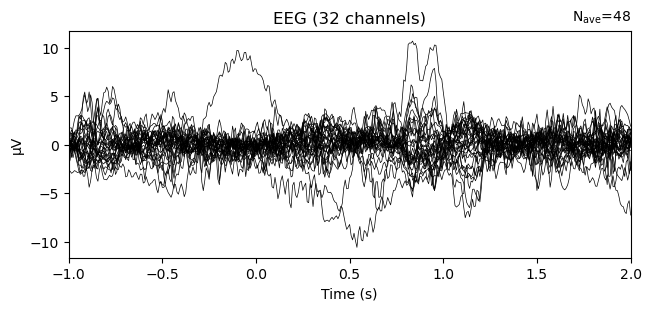

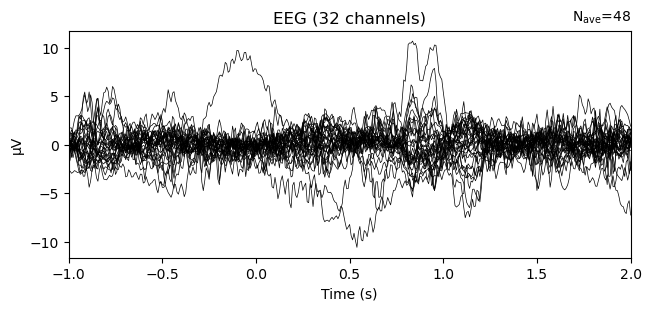

In [26]:
evoked_subject01 = epochs_subject01.average()
evoked_subject01.plot()

Aktueller Ordner: E:\eeg-flex2-pipeline
Gespeichert unter: E:\eeg-flex2-pipeline\outputs\figures\subject01_event_7711_average.png


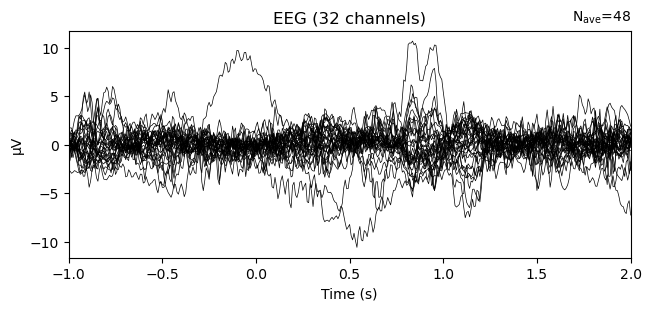

In [28]:
from pathlib import Path

print("Aktueller Ordner:", Path.cwd())

out_dir = Path("outputs/figures")
out_dir.mkdir(parents=True, exist_ok=True)

fig = evoked_subject01.plot(show=False)

save_path = out_dir / "subject01_event_7711_average.png"
fig.savefig(save_path, dpi=150)

print("Gespeichert unter:", save_path.resolve())

In [ ]:
processed_dir = Path("data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

epochs_path = processed_dir / "subject01_event_7711_epochs-epo.fif"

epochs_subject01.save(
    epochs_path,
    overwrite=True
)

print("Epochs gespeichert unter:", epochs_path.resolve())

In [ ]:
subject_dirs = sorted([
    p for p in raw_dir.glob("SUBJECT*")
    if p.is_dir()
])

print("Gefundene Subjects:", len(subject_dirs))

for s in subject_dirs[:10]:
    print(s.name)

In [ ]:
test_subject_dirs = subject_dirs[:3]

all_epochs_test = []

for subject_dir in test_subject_dirs:
    eeg_files = sorted(subject_dir.glob("*_EEG.csv"))
    
    print(f"\nVerarbeite {subject_dir.name}: {len(eeg_files)} EEG-Dateien")
    
    for csv_file in eeg_files:
        try:
            raw_tmp, df_tmp = load_eeg_csv_as_raw(csv_file)
            events_tmp = extract_events_from_df(df_tmp)

            raw_tmp.filter(
                l_freq=1.0,
                h_freq=40.0,
                picks="eeg",
                verbose=False
            )

            raw_tmp.set_eeg_reference("average", verbose=False)

            epochs_tmp = mne.Epochs(
                raw_tmp,
                events_tmp,
                event_id={"event_7711": 7711},
                tmin=-1.0,
                tmax=2.0,
                baseline=(-1.0, 0.0),
                picks="eeg",
                preload=True,
                verbose=False
            )

            if len(epochs_tmp) > 0:
                all_epochs_test.append(epochs_tmp)
                print(f"  {csv_file.name}: {len(epochs_tmp)} Epochs")
            else:
                print(f"  {csv_file.name}: keine Epochs")

        except Exception as e:
            print("  Fehler bei", csv_file.name, ":", e)

epochs_test = mne.concatenate_epochs(all_epochs_test)

print(epochs_test)

In [ ]:
all_epochs = []

for subject_dir in subject_dirs:
    eeg_files = sorted(subject_dir.glob("*_EEG.csv"))
    
    print(f"\nVerarbeite {subject_dir.name}: {len(eeg_files)} EEG-Dateien")
    
    for csv_file in eeg_files:
        try:
            raw_tmp, df_tmp = load_eeg_csv_as_raw(csv_file)
            events_tmp = extract_events_from_df(df_tmp)

            raw_tmp.filter(
                l_freq=1.0,
                h_freq=40.0,
                picks="eeg",
                verbose=False
            )

            raw_tmp.set_eeg_reference("average", verbose=False)

            epochs_tmp = mne.Epochs(
                raw_tmp,
                events_tmp,
                event_id={"event_7711": 7711},
                tmin=-1.0,
                tmax=2.0,
                baseline=(-1.0, 0.0),
                picks="eeg",
                preload=True,
                verbose=False
            )

            if len(epochs_tmp) > 0:
                all_epochs.append(epochs_tmp)

        except Exception as e:
            print("Fehler bei", csv_file.name, ":", e)

epochs_all = mne.concatenate_epochs(all_epochs)

print(epochs_all)

In [33]:
bad_file = raw_dir / "SUBJECT13" / "SUBJECT13_Trial_02_EEG.csv"

df_bad = pd.read_csv(bad_file)

print("Shape:", df_bad.shape)
print("Columns:")
print(df_bad.columns.tolist())
df_bad.head()


Shape: (77707, 2)
Columns:
['Triggers', '0']


,Triggers,0
0,32766,26
1,771,268
2,0,265
3,0,267
4,0,270


In [34]:
expected_cols = [str(i) for i in range(2, 34)]

good_files = []
bad_files = []

for subject_dir in subject_dirs:
    eeg_files = sorted(subject_dir.glob("*_EEG.csv"))
    
    for csv_file in eeg_files:
        try:
            df_check = pd.read_csv(csv_file)
            df_check.columns = [str(c).strip() for c in df_check.columns]
            
            if all(c in df_check.columns for c in expected_cols):
                good_files.append(csv_file)
            else:
                bad_files.append(csv_file)
                
        except Exception:
            bad_files.append(csv_file)

print("Gute EEG-Dateien:", len(good_files))
print("Kaputte/ungeeignete EEG-Dateien:", len(bad_files))

for f in bad_files:
    print("BAD:", f)

Gute EEG-Dateien: 193
Kaputte/ungeeignete EEG-Dateien: 1
BAD: data\raw\SUBJECT13\SUBJECT13_Trial_02_EEG.csv


In [35]:
all_epochs = []

for csv_file in good_files:
    try:
        raw_tmp, df_tmp = load_eeg_csv_as_raw(csv_file)
        events_tmp = extract_events_from_df(df_tmp)

        raw_tmp.filter(
            l_freq=1.0,
            h_freq=40.0,
            picks="eeg",
            verbose=False
        )

        raw_tmp.set_eeg_reference("average", verbose=False)

        epochs_tmp = mne.Epochs(
            raw_tmp,
            events_tmp,
            event_id={"event_7711": 7711},
            tmin=-1.0,
            tmax=2.0,
            baseline=(-1.0, 0.0),
            picks="eeg",
            preload=True,
            verbose=False
        )

        if len(epochs_tmp) > 0:
            all_epochs.append(epochs_tmp)

    except Exception as e:
        print("Fehler bei", csv_file, ":", e)

epochs_all = mne.concatenate_epochs(all_epochs)

print(epochs_all)

Not setting metadata
1844 matching events found
Applying baseline correction (mode: mean)
<EpochsArray | 1844 events (all good), -1 – 2 s (baseline -1 – 0 s), ~173.4 MiB, data loaded,
 'event_7711': 1844>


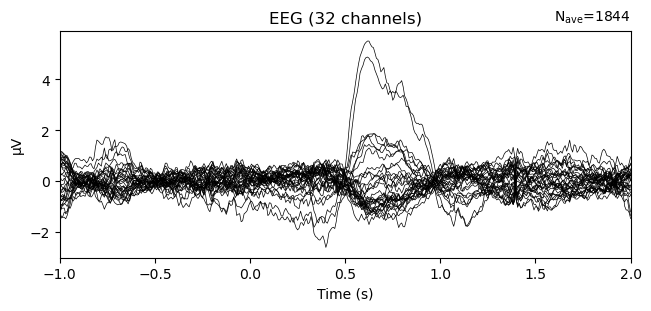

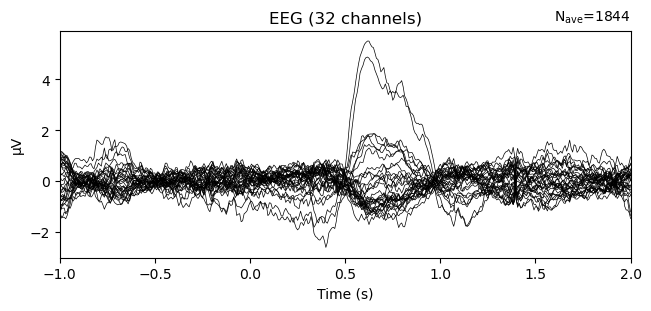

In [36]:
evoked_all = epochs_all.average()
evoked_all.plot()

Epochs gespeichert: E:\eeg-flex2-pipeline\data\processed\all_subjects_event_7711_epochs-epo.fif
Plot gespeichert: E:\eeg-flex2-pipeline\outputs\figures\all_subjects_event_7711_average.png


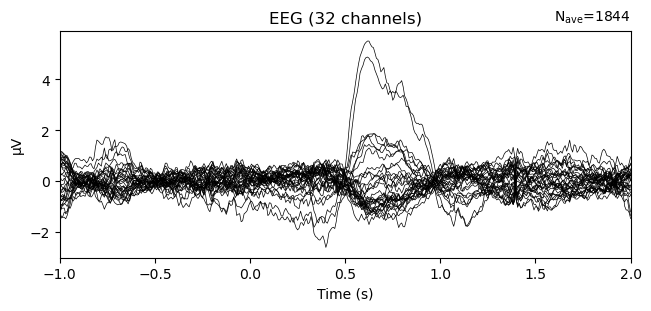

In [37]:
processed_dir = Path("data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

figures_dir = Path("outputs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

epochs_all_path = processed_dir / "all_subjects_event_7711_epochs-epo.fif"
epochs_all.save(epochs_all_path, overwrite=True)

fig = evoked_all.plot(show=False)
fig_path = figures_dir / "all_subjects_event_7711_average.png"
fig.savefig(fig_path, dpi=150)

print("Epochs gespeichert:", epochs_all_path.resolve())
print("Plot gespeichert:", fig_path.resolve())

In [38]:
from pathlib import Path

src_dir = Path("src")
src_dir.mkdir(exist_ok=True)

pipeline_code = r'''
from pathlib import Path
import pandas as pd
import numpy as np
import mne

SFREQ = 128
EEG_COLS = [str(i) for i in range(2, 34)]

def load_eeg_csv_as_raw(csv_path, sfreq=SFREQ):
    csv_path = Path(csv_path)
    df = pd.read_csv(csv_path)
    df.columns = [str(c).strip() for c in df.columns]

    missing_cols = [c for c in EEG_COLS if c not in df.columns]
    if missing_cols:
        raise ValueError(
            f"Datei hat keine vollständigen EEG-Kanäle. "
            f"Shape={df.shape}, fehlende Spalten={missing_cols[:5]}"
        )

    eeg_data = df[EEG_COLS].to_numpy().T * 1e-6
    stim_data = df["Triggers"].to_numpy()[None, :]

    data = np.vstack([eeg_data, stim_data])

    ch_names = [f"EEG{i+1:02d}" for i in range(32)] + ["STI 014"]
    ch_types = ["eeg"] * 32 + ["stim"]

    info = mne.create_info(
        ch_names=ch_names,
        sfreq=sfreq,
        ch_types=ch_types
    )

    raw = mne.io.RawArray(data, info, verbose=False)
    return raw, df


def extract_events_from_df(df):
    trig = df["Triggers"].to_numpy()

    event_samples = np.where((trig != 0) & (np.r_[0, trig[:-1]] == 0))[0]
    event_ids = trig[event_samples].astype(int)

    events = np.column_stack([
        event_samples,
        np.zeros(len(event_samples), dtype=int),
        event_ids
    ])

    return events


def find_good_eeg_files(raw_dir):
    raw_dir = Path(raw_dir)
    subject_dirs = sorted([p for p in raw_dir.glob("SUBJECT*") if p.is_dir()])

    good_files = []
    bad_files = []

    for subject_dir in subject_dirs:
        eeg_files = sorted(subject_dir.glob("*_EEG.csv"))

        for csv_file in eeg_files:
            try:
                df_check = pd.read_csv(csv_file)
                df_check.columns = [str(c).strip() for c in df_check.columns]

                if all(c in df_check.columns for c in EEG_COLS):
                    good_files.append(csv_file)
                else:
                    bad_files.append(csv_file)

            except Exception:
                bad_files.append(csv_file)

    return good_files, bad_files


def build_epochs_from_files(
    eeg_files,
    event_code=7711,
    l_freq=1.0,
    h_freq=40.0,
    tmin=-1.0,
    tmax=2.0,
    baseline=(-1.0, 0.0),
):
    all_epochs = []

    for csv_file in eeg_files:
        raw, df = load_eeg_csv_as_raw(csv_file)
        events = extract_events_from_df(df)

        raw.filter(
            l_freq=l_freq,
            h_freq=h_freq,
            picks="eeg",
            verbose=False
        )

        raw.set_eeg_reference("average", verbose=False)

        epochs = mne.Epochs(
            raw,
            events,
            event_id={f"event_{event_code}": event_code},
            tmin=tmin,
            tmax=tmax,
            baseline=baseline,
            picks="eeg",
            preload=True,
            verbose=False
        )

        if len(epochs) > 0:
            all_epochs.append(epochs)

    if not all_epochs:
        raise RuntimeError("Keine gültigen Epochs gefunden.")

    return mne.concatenate_epochs(all_epochs)
'''

pipeline_path = src_dir / "eeg_pipeline.py"
pipeline_path.write_text(pipeline_code, encoding="utf-8")

print("Pipeline gespeichert unter:", pipeline_path.resolve())

Pipeline gespeichert unter: E:\eeg-flex2-pipeline\src\eeg_pipeline.py


In [39]:
from src.eeg_pipeline import find_good_eeg_files, build_epochs_from_files

raw_dir = Path("data/raw")

good_files, bad_files = find_good_eeg_files(raw_dir)

print("Gute Dateien:", len(good_files))
print("Kaputte Dateien:", len(bad_files))

Gute Dateien: 193
Kaputte Dateien: 1
